In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploring the Association Between Diet and Depression: A Cross-Country Analysis


## Introduction

Depression is one of the leading causes of disability worldwide, affecting an estimated **332 million people** according to the [World Health Organization](https://www.who.int/news-room/fact-sheets/detail/depression). It is still widely assumed that depression is primarily a psychological condition - something rooted in thoughts, mindset, or life circumstances. However, growing research suggests that the picture is far more complex.

Evidence points to a physiological component involving the dysregulation of three interconnected biological systems([Vinkers et al.,2021](https://pubmed.ncbi.nlm.nih.gov/33549878/)):
- The **hypothalamic-pituitary-adrenal (HPA) axis**, which governs the stress response
- The **immune system**, where chronic low-grade inflammation has been linked to depressive episodes ([Berk et al., 2013](https://doi.org/10.1186/1741-7015-11-200))
- The **autonomic nervous system (ANS)**, which regulates involuntary physiological functions

One factor in this biological pathway is diet. Poor nutrition can drive systemic inflammation, disrupt gut microbiota, and impair neurotransmitter synthesis - all mechanisms with plausible links to depression. A 2017 meta-analysis published in *Psychosomatic Medicine* found that a healthy diet was associated with a significantly reduced risk of depression ([Li et al., 2017](https://doi.org/10.1016/j.psychres.2017.04.020)).

Because country-level dietary quality data is difficult to obtain consistently, this project uses obesity rates as a proxy for poor nutrition. Obesity is strongly associated with diets high in ultra-processed foods, refined sugars, and low in micronutrients - the same dietary patterns implicated in depression risk 
([Gómez-Donoso et al., 2020](https://doi.org/10.3390/nu14132568)).

This project investigates whether obesity rates correlate with depression rates across countries, using publicly available global health data.

## Hypothesis

Since obesity is strongly associated with poor dietary habits ([Afshin et al., 2019](https://doi.org/10.1016/S0140-6736(19)30041-8)), we use it as a country-level proxy for nutritional quality.

**H1:** Countries with higher obesity rates will show higher rates of depressive disorders.

We will test this both as a **cross-country snapshot** (comparing countries at a single point in time) and as a **within-country trend** (examining whether changes in obesity within a country co-occur with changes in depression over time).

## Data

We use two datasets: 

1. **Mental Health Data** - prevalence of depressive disorders as a share of population, age-standardized, across countries and years [Kaggle](https://www.kaggle.com/datasets/imtkaggleteam/mental-health?select=1-+mental-illnesses-prevalence.csv).
2. **Obesity Data** - share of adults with BMI ≥ 25 (overweight/obese), age-standardized, across countries and years [Our World in Data](https://ourworldindata.org/grapher/share-of-adults-who-are-overweight).

BMI (Body Mass Index) is calculated as:
$$
\mathrm{BMI} = \frac{m}{h^2}
$$
where $m$ is mass in kilograms and $h$ is height in metres. A BMI of 25 or above is classified as overweight by the [WHO](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight).

### Loading the Data

In [2]:
mental_health = pd.read_csv('mental-health-data/mental-illnesses-prevalence.csv')
obesity = pd.read_csv('obesity-data/share-of-adults-who-are-overweight.csv')

In [3]:
print('Mental health dataset:')
print(f'  Rows: {mental_health.shape[0]}, Columns: {mental_health.shape[1]}')
print(f'  Years: {mental_health.Year.min()}–{mental_health.Year.max()}')
print(f'  Entities: {mental_health.Entity.nunique()}')
print()
print('Obesity dataset:')
print(f'  Rows: {obesity.shape[0]}, Columns: {obesity.shape[1]}')
print(f'  Years: {obesity.Year.min()}–{obesity.Year.max()}')
print(f'  Entities: {obesity.Entity.nunique()}')

Mental health dataset:
  Rows: 6420, Columns: 8
  Years: 1990–2019
  Entities: 214

Obesity dataset:
  Rows: 6798, Columns: 4
  Years: 1990–2022
  Entities: 206


### Merging & Cleaning

The two datasets differ in the number of entities (countries, regions, aggregates) they cover. To ensure we only work with rows that exist in both datasets, we perform an inner merge on `Entity` and `Year`. This automatically drops any country-year combinations that appear in only one of the datasets.

In [4]:
# Merge both tables on Entity and Year (inner join — keeps only shared country-year pairs)
obesity_mental_health_df = pd.merge(mental_health, obesity, on=['Entity', 'Year'])

After merging, we reduce the table to only the columns relevant to our analysis and rename them for readability. We will also keep the anxiety column - we will use it later to compare whether the obesity-anxiety relationship differs from the obesity-depression one.

In [5]:
# Reduce to relevant columns only
obesity_mental_health_df = obesity_mental_health_df[[
    "Entity",
    "Year",
    "Depressive disorders (share of population) - Sex: Both - Age: Age-standardized",
    "Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized",
    "Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+  years of age"
]]

In [6]:
# Rename columns for readability
obesity_mental_health_df = obesity_mental_health_df.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Depressive disorders (share of population) - Sex: Both - Age: Age-standardized": "depressive_disorders",
    "Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized": "anxiety_disorders",
    "Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+  years of age": "obesity_rate"
})

### Exploratory Overview
Before starting the analysis, we take a quick look at the merged dataset to understand its shape, value ranges, and whether anything looks unexpected.

In [7]:
# Checking for missing countries since they must be 206 after the merge
print(f'Merged dataset: {obesity_mental_health_df.shape[0]} rows, {obesity_mental_health_df.country.nunique()} entities')

Merged dataset: 5970 rows, 199 entities


In [8]:
missing_from_obesity = set(obesity.Entity.unique()) - set(obesity_mental_health_df.country.unique())
missing_from_mental_health = set(mental_health.Entity.unique()) - set(obesity_mental_health_df.country.unique())

print(f'Entities in obesity data not in merged dataset ({len(missing_from_obesity)}):')
print(missing_from_obesity)
print()
print(f'Entities in mental health data not in merged dataset ({len(missing_from_mental_health)}):')
print(missing_from_mental_health)

Entities in obesity data not in merged dataset (7):
{'Africa (WHO)', 'Americas (WHO)', 'Eastern Mediterranean (WHO)', 'Europe (WHO)', 'South-East Asia (WHO)', 'French Polynesia', 'Western Pacific (WHO)'}

Entities in mental health data not in merged dataset (15):
{'United States Virgin Islands', 'America (IHME GBD)', 'European Union (27)', 'Taiwan', 'Asia (IHME GBD)', 'Guam', 'Northern Mariana Islands', 'Monaco', 'San Marino', 'Europe (IHME GBD)', 'Low-income countries', 'Lower-middle-income countries', 'Africa (IHME GBD)', 'High-income countries', 'Upper-middle-income countries'}


The dropped entries appear to be regional aggregates (such as "Europe (WHO)" or "High-income countries") and small territories. We note their absence but do not investigate further as the focus of this project is on individual countries.

In [9]:
obesity_mental_health_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5970.0,2004.500000,8.656166,1990.000000,1997.000000,2004.500000,2012.000000,2019.000000
depressive_disorders,5970.0,3.780257,0.944505,1.522333,3.066551,3.655919,4.389562,7.645899
anxiety_disorders,5970.0,4.087335,1.067037,1.879996,3.416398,3.932944,4.521156,8.624634
obesity_rate,5970.0,42.927505,19.704198,2.817660,26.453363,46.536270,55.506020,91.284530


A few things stand out from the summary statistics:

- Depression rates range from 1.5% to 7.6% and anxiety from 1.9% to 8.6% - both show variation across countries, which is a basis for a cross-country comparison.
- Obesity rates range from 2.8% to 91.3% - the upper end appears extreme and may reflect countries with atypical population characteristics. Investigating and potentially excluding these outliers is noted as a limitation of this analysis.
- The year range spans 1990 to 2019, giving us almost three decades of data.

## Analysis

We approach the hypothesis from two angles:
1. **Within-country examination** - when obesity rises inside a country over time, does depression follow?
2. **Cross-country examination** - do countries with higher obesity tend to have higher depression rates?


### Part 1: Within-Country Examination

**When obesity increases within a specific country over time, does depression also increase?** This approach controls for country-level fixed factors (culture, healthcare, reporting norms) by looking only at *changes* within each country year-over-year.

We compute year-over-year differences for both obesity and depression for each country using `.diff()` grouped by country.

In [34]:
obesity_change = obesity_mental_health_df.groupby("country")["obesity_rate"].diff()
depression_change = obesity_mental_health_df.groupby("country")["depressive_disorders"].diff()

print(f"Obesity change vs. Depression change: {obesity_change.corr(depression_change):.3f}")

Obesity change vs. Depression change: 0.047


In [24]:
# Correlation between year-over-year changes
print(f"Obesity change vs. Depression change: {obesity_mental_health_df['obesity_change'].corr(obesity_mental_health_df['depression_change']):.3f}")

Obesity change vs. Depression change: 0.047


The year-over-year change correlation is essentially flat - near zero. To understand why, we can look at a representative country. Depression rates are remarkably stable within individual countries over time, meaning there is very little signal for year-over-year analysis to detect.

The plot below is the average for all countries and illustrates this:

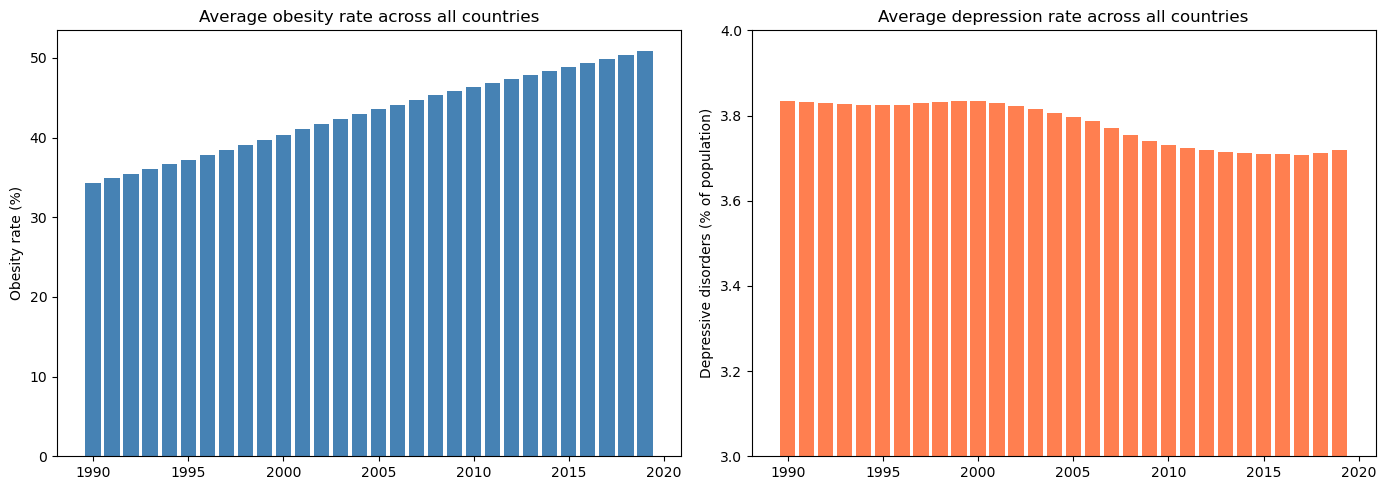

In [12]:
yearly_avg = obesity_mental_health_df.groupby("year")[
    ["obesity_rate", "depressive_disorders"]
].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(yearly_avg.index, yearly_avg["obesity_rate"], color="steelblue")
ax1.set_title("Average obesity rate across all countries")
ax1.set_ylabel("Obesity rate (%)")

ax2.bar(yearly_avg.index, yearly_avg["depressive_disorders"], color="coral")
ax2.set_title("Average depression rate across all countries")
ax2.set_ylabel("Depressive disorders (% of population)")
ax2.set_ylim(3.0, 4.0)

plt.tight_layout()
plt.show()

While obesity rises steadily, depression rates remain almost completely flat within the countries over the same period.

The near-zero correlation suggests that year-over-year changes in obesity within a country are not accompanied by measurable changes in depression over the same period. We cannot draw conclusions about why from this data alone. What we can say is that a within-country approach does not appear useful for testing our hypothesis here, and we move to cross-country comparisons instead.

### Part 2: Cross-Country Examination

We start by looking at a single year snapshot - 2019 - to compare countries at the same point in time. Using a single year avoids the confounding effect of global trends (e.g., both obesity and depression rising everywhere over time simply due to better reporting).

We use Pearson correlation and a regression plot to assess the direction and strength of the relationship.

In [13]:
# Why Am I taking the last year - explain.
obesity_depression_2019 = obesity_mental_health_df[obesity_mental_health_df["year"] == 2019]

In [14]:
# Pearson correlation between obesity rate and depression rate (2019)
obesity_depression_2019["obesity_rate"].corr(obesity_depression_2019["depressive_disorders"])

np.float64(-0.352589199468664)

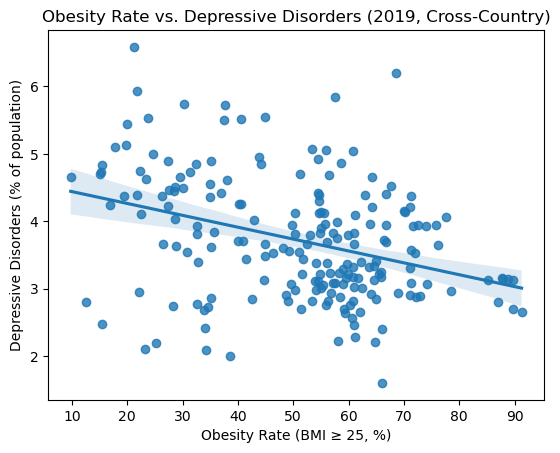

In [15]:
sns.regplot(data=obesity_depression_2019, x="obesity_rate", y="depressive_disorders")
plt.title("Obesity Rate vs. Depressive Disorders (2019, Cross-Country)")
plt.xlabel("Obesity Rate (BMI ≥ 25, %)")
plt.ylabel("Depressive Disorders (% of population)")
plt.show()

A **weak negative association** is observed between obesity and depression across countries. This is a counterintuitive result - it suggests that at the country level, higher obesity does not straightforwardly correspond to higher depression. 

This is likely influenced by confounding variables such as economic development, healthcare access, reporting quality and other health variables contributing to depression.

#### Segmentation Analysis

Looking at the regression plot, there appears to be a sligth structural difference between countries with lower vs. higher obesity rates - the variability in depression rates increases at lower obesity levels. We split the data at the 45% obesity rate threshold to examine whether the relationship behaves differently in each group.

In [17]:
low = obesity_depression_2019[obesity_depression_2019["obesity_rate"] < 45]
high = obesity_depression_2019[obesity_depression_2019["obesity_rate"] >= 45]

print("Depression correlation:")
print(f"  Low obesity group:  {low['obesity_rate'].corr(low['depressive_disorders']):.3f}")
print(f"  High obesity group: {high['obesity_rate'].corr(high['depressive_disorders']):.3f}")

Depression correlation:
  Low obesity group:  -0.138
  High obesity group: -0.128


The negative association that appeared in the overall data **weakens significantly after segmentation**. This is an example of [**Simpson's Paradox**](https://en.wikipedia.org/wiki/Simpson%27s_paradox) - a trend that appears in aggregated data can disappear or reverse when the data is split into subgroups. Here, the overall correlation is likely being driven by structural differences *between* the two groups (e.g., low-obesity countries being predominantly lower-income with different reporting norms) rather than a genuine within-group relationship between obesity and depression.

We confirm this pattern holds across all years, not just 2019:

In [18]:
# Overall correlation across all countries and all years
print("Overall (all years):")
print(f"  Obesity vs. Depression: {obesity_mental_health_df['obesity_rate'].corr(obesity_mental_health_df['depressive_disorders']):.3f}")

Overall (all years):
  Obesity vs. Depression: -0.335


In [19]:
# Segmented correlation across all years
low_all = obesity_mental_health_df[obesity_mental_health_df["obesity_rate"] < 45]
high_all = obesity_mental_health_df[obesity_mental_health_df["obesity_rate"] >= 45]

print("Depression correlation (all years, segmented):")
print(f"  Low obesity group:  {low_all['obesity_rate'].corr(low_all['depressive_disorders']):.3f}")
print(f"  High obesity group: {high_all['obesity_rate'].corr(high_all['depressive_disorders']):.3f}")

Depression correlation (all years, segmented):
  Low obesity group:  -0.279
  High obesity group: -0.131


The segmentation finding holds across all years. The relationship between obesity and depression varies depending on the level of aggregation, and disappears within homogeneous subgroups - reinforcing the Simpson's Paradox interpretation, suggesting there is no correlation between onbesity and depression.

#### High-Income Countries

The global cross-country analysis produced a weak and inconsistent result. One likely reason is that we are mixing countries where fundamentally different mechanisms drive depression:

- **Low-income countries** - depression is more likely driven by nutrient scarcity, food insecurity, and limited healthcare access.
- **High-income countries** - food scarcity is not the issue. The concern is the opposite: diets high in processed foods and refined ingredients despite adequate calories.

Our hypothesis is specifically about the second mechanism. We therefore restrict the analysis to a group of high-income countries where dietary excess - rather than deficiency - is the dominant nutritional reality, and where depression is measured and reported in a comparable way across the group.

In [26]:
high_income_countries = [
    'Australia', 'Austria', 'Belgium', 'Canada', 'Denmark',
    'Finland', 'France', 'Germany', 'Ireland', 'Italy',
    'Japan', 'Netherlands', 'New Zealand', 'Norway', 'Portugal',
    'Spain', 'Sweden', 'Switzerland', 'United Kingdom', 'United States'
]

# The Organization for Economic Cooperation and Development (OECD) - primarily high-income economies committed to democracy and market economies.
oecd_df = obesity_mental_health_df[obesity_mental_health_df['country'].isin(high_income_countries)]
print(f'Countries included: {oecd_df["country"].nunique()}')
print(f'Year range: {oecd_df["year"].min()} to {oecd_df["year"].max()}')

Countries included: 20
Year range: 1990 to 2019


In [28]:
# Average each country across all years
oecd_avg = oecd_df.groupby('country')[['obesity_rate', 'depressive_disorders']].mean().reset_index()

We average both variables across all available years per country. Since depression rates are structurally stable over time - as shown in Part 1 - this does not distort the depression signal, while averaging obesity produces a more robust country-level estimate than picking any single year.

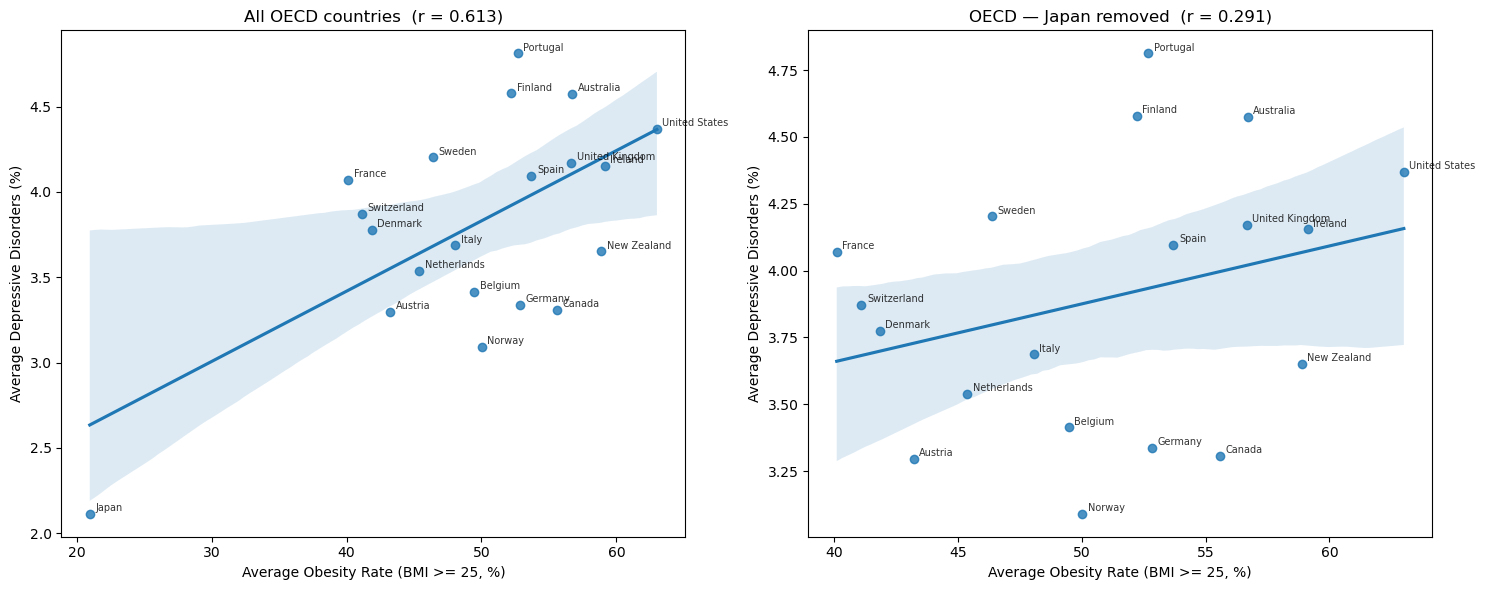

In [29]:
# Plots a regression scatter with country labels and correlation in the title

def plot_corr(df, x, y, title, ax):
    sns.regplot(data=df, x=x, y=y, ax=ax)
    for _, row in df.iterrows():
        ax.annotate(row['country'], (row[x], row[y]),
                    fontsize=7, alpha=0.8, xytext=(4, 2), textcoords='offset points')
    r = df[x].corr(df[y])
    ax.set_title(f'{title}  (r = {r:.3f})')
    ax.set_xlabel('Average Obesity Rate (BMI >= 25, %)')
    ax.set_ylabel('Average Depressive Disorders (%)')

# Left plot: all OECD countries
# Right plot: same but with Japan removed to test how much it influences the result
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plot_corr(oecd_avg, 'obesity_rate', 'depressive_disorders', 'All OECD countries', ax1)
plot_corr(oecd_avg[oecd_avg['country'] != 'Japan'], 'obesity_rate', 'depressive_disorders', 'OECD — Japan removed', ax2)
plt.tight_layout()
plt.show()

Japan sits at the low-depression end of the plot, but this is misleading. Japan has one of the highest suicide rates among high-income countries ([WPR](https://worldpopulationreview.com/country-rankings/suicide-rate-by-country)) despite very low reported depression a - well-documented cultural phenomenon where mental illness carries strong stigma and is routinely underdiagnosed ([Hori et al. (2019)](https://pmc.ncbi.nlm.nih.gov/articles/PMC6778451/)). This makes Japan an unreliable data point rather than a genuine outlier, and it's worth checking how much weight it carries in our correlation.

Removing Japan drops the correlation significantly, which tells us the OECD result is not as robust as the 0.613 number suggests - it leans heavily on one country whose data we have reason to distrust. This is an important limitation to acknowledge: the relationship between obesity and depression across high-income countries exists directionally, but the strength of the signal depends on how you handle cultural reporting differences.

## Conclusion

## Limitations

## Resources

- WHO - Depression fact sheet: https://www.who.int/news-room/fact-sheets/detail/depression
- WHO - Obesity and overweight: https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight
- Vinkers et al. (2021) - An integrated approach to understand biological stress system dysregulation across depressive and anxiety disorders: https://pubmed.ncbi.nlm.nih.gov/33549878/
- Berk et al. (2013) - So depression is an inflammatory disease, but where does the inflammation come from? https://doi.org/10.1186/1741-7015-11-200
- Li et al. (2017) - Dietary patterns and depression risk: A meta-analysis : https://doi.org/10.1016/j.psychres.2017.04.020
- Gómez-Donoso et al., (2020) - Ultra-Processed Food Consumption and Mental Health: A Systematic Review and Meta-Analysis of Observational Studies https://doi.org/10.3390/nu14132568
- Afshin et al. (2019) - Health effects of dietary risks in 195 countries: https://doi.org/10.1016/S0140-6736(19)30041-8
- Wikipedia - BMI: https://en.wikipedia.org/wiki/Body_mass_index
- Wikipedia - Simpson's Paradox: https://en.wikipedia.org/wiki/Simpson%27s_paradox
- pandas documentation - Merging: https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html
- Our World in Data - Mental Health: https://ourworldindata.org/mental-health
- Our World in Data - Obesity: https://ourworldindata.org/obesity
- World Population Review - https://worldpopulationreview.com/country-rankings/suicide-rate-by-country
- Hori et al. (2019) — Assessment of current clinical practices for major depression in Japan: https://pmc.ncbi.nlm.nih.gov/articles/PMC6778451/